# 01. 국가 환경 점수 — K-Means 군집화

**계획**: 데이터 확인 → 전처리 → 모델링 → 하이퍼파라미터 튜닝 → 학습

- 입력: `data/processed/Living_Abroad_ML_Training_Dataset_v1.0.xlsx` (`ML_CLUSTER_INPUT` 시트, 36개국)
- 목표: 전체 36개국으로 국가 환경 군집을 학습하고, 캐나다·호주·영국 3개국의 결과만 조회한다.
- 산출물: `ai-server/models/environment_kmeans.joblib`, `environment_scaler.joblib`, `environment_features.json`
- 주의: `environment_score_rule_based`는 정답 라벨로 사용하지 않는다 (DATA_DICTIONARY 명시). `iso3`, `country_name`도 학습 입력에서 제외한다.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"  # 그래프 한글 라벨이 깨지지 않도록 설정
plt.rcParams["axes.unicode_minus"] = False

# 노트북은 ai-server/notebooks/ 에서 실행한다고 가정한다.
DATA_PATH = Path("../../data/processed/Living_Abroad_ML_Training_Dataset_v1.0.xlsx")
OUTPUT_DIR = Path("../../output/01_environment_kmeans")
MODELS_DIR = Path("../models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MVP_COUNTRIES = ["CAN", "AUS", "GBR"]
RANDOM_STATE = 42

## 1. 데이터 확인

In [2]:
df = pd.read_excel(DATA_PATH, sheet_name="ML_CLUSTER_INPUT")
print("국가 수:", len(df))
print("컬럼 수:", len(df.columns))
df[["iso3", "country_name"]].head(10)

국가 수: 36
컬럼 수: 31


,iso3,country_name
0,AUS,Australia
1,AUT,Austria
2,BEL,Belgium
3,CAN,Canada
4,CHE,Switzerland
5,CHL,Chile
6,COL,Colombia
7,CZE,Czechia
8,DEU,Germany
9,DNK,Denmark


In [3]:
RAW_FEATURES = [
    "log10_migrant_stock_2024",
    "stock_growth_2020_2024_pct",
    "female_share_2024_pct",
    "inflow_growth_5y_pct",
    "foreign_population_pct_latest",
    "foreign_born_pct_latest",
    "nationality_acquisition_rate_pct_latest",
    "foreign_born_employment_rate_pct",
    "foreign_born_high_education_share_pct",
]

missing_counts = df[RAW_FEATURES].isna().sum().sort_values(ascending=False)
missing_counts

foreign_born_employment_rate_pct           10
foreign_born_high_education_share_pct       9
foreign_population_pct_latest               4
nationality_acquisition_rate_pct_latest     3
foreign_born_pct_latest                     2
inflow_growth_5y_pct                        1
log10_migrant_stock_2024                    0
stock_growth_2020_2024_pct                  0
female_share_2024_pct                       0
dtype: int64

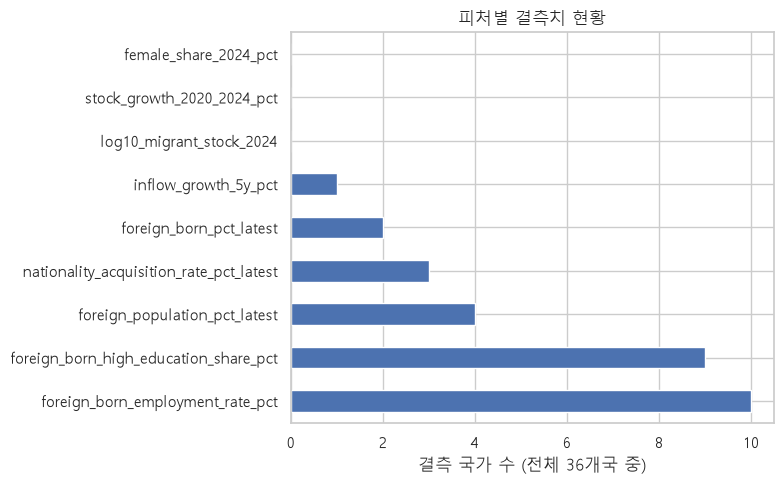

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
missing_counts.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("결측 국가 수 (전체 36개국 중)")
ax.set_title("피처별 결측치 현황")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_missing_values.png", dpi=150)
plt.show()

## 2. 전처리

결측치는 중앙값으로 대체한 뒤 Min-Max Scaling을 적용한다 (README에 기술된 원본 전처리 방식과 동일).
이미 계산되어 있는 `*_scaled` 컬럼과 직접 비교해 전처리 로직이 일치하는지 검증한다.

In [5]:
X_raw = df[RAW_FEATURES].copy()
X_imputed = X_raw.fillna(X_raw.median())

# 재사용 가능한 프로덕션 스케일러: 원본 결측치를 중앙값으로 대체한 뒤 학습한다.
# (향후 새 국가 데이터가 추가될 때 동일한 기준으로 스케일링하기 위한 아티팩트)
scaler = MinMaxScaler()
X_scaled_self = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=RAW_FEATURES,
    index=df.index,
)
X_scaled_self.describe().round(3)

,log10_migrant_stock_2024,stock_growth_2020_2024_pct,female_share_2024_pct,inflow_growth_5y_pct,foreign_population_pct_latest,foreign_born_pct_latest,nationality_acquisition_rate_pct_latest,foreign_born_employment_rate_pct,foreign_born_high_education_share_pct
count,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000
mean,0.459,0.202,0.482,0.296,0.203,0.277,0.225,0.606,0.478
std,0.226,0.179,0.189,0.209,0.175,0.194,0.216,0.200,0.222
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.334,0.099,0.386,0.151,0.134,0.141,0.098,0.496,0.379
50%,0.457,0.145,0.477,0.250,0.169,0.269,0.171,0.619,0.478
75%,0.591,0.229,0.532,0.383,0.243,0.361,0.260,0.705,0.557
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [6]:
provided_scaled_cols = [f"{c}_scaled" for c in RAW_FEATURES]
X_scaled = df[provided_scaled_cols].copy()
X_scaled.columns = RAW_FEATURES

per_column_diff = (X_scaled_self - X_scaled).abs().max().sort_values(ascending=False)
print("컬럼별 최대 절대 오차 (자체 스케일링 vs 원본 *_scaled):")
print(per_column_diff.round(4))
print(
    "\n대부분 0에 가깝고, 결측치가 있던 컬럼에서만 소폭 차이가 납니다."
    " 원본은 '스케일링 후 결측 대체', 이 노트북의 scaler는 '결측 대체 후 스케일링' 순서라 "
    "결측 셀에서만 차이가 발생합니다 (비결측 값은 일치).\n"
    "모델링에는 DATA_DICTIONARY가 지정한 원본 *_scaled 컬럼(X_scaled)을 그대로 사용합니다."
)

컬럼별 최대 절대 오차 (자체 스케일링 vs 원본 *_scaled):
female_share_2024_pct                      0.5057
log10_migrant_stock_2024                   0.4885
stock_growth_2020_2024_pct                 0.1368
foreign_born_high_education_share_pct      0.0177
foreign_born_employment_rate_pct           0.0034
inflow_growth_5y_pct                       0.0001
nationality_acquisition_rate_pct_latest    0.0000
foreign_population_pct_latest              0.0000
foreign_born_pct_latest                    0.0000
dtype: float64

대부분 0에 가깝고, 결측치가 있던 컬럼에서만 소폭 차이가 납니다. 원본은 '스케일링 후 결측 대체', 이 노트북의 scaler는 '결측 대체 후 스케일링' 순서라 결측 셀에서만 차이가 발생합니다 (비결측 값은 일치).
모델링에는 DATA_DICTIONARY가 지정한 원본 *_scaled 컬럼(X_scaled)을 그대로 사용합니다.


## 3. 모델링 — Elbow Method + Silhouette Score

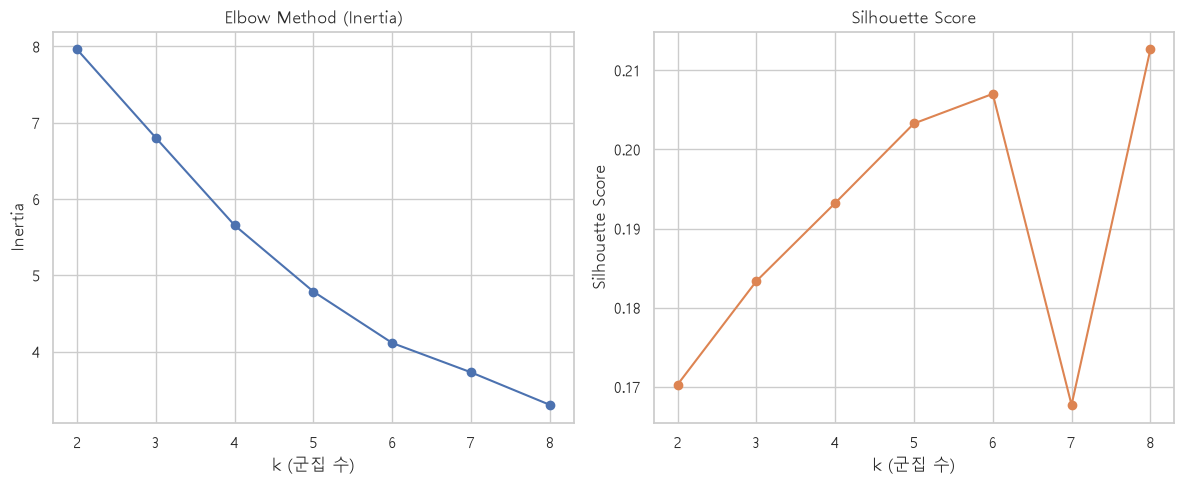

k=2: silhouette=0.1703
k=3: silhouette=0.1833
k=4: silhouette=0.1932
k=5: silhouette=0.2033
k=6: silhouette=0.2070
k=7: silhouette=0.1677
k=8: silhouette=0.2126


In [7]:
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("k (군집 수)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k (군집 수)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_elbow_silhouette.png", dpi=150)
plt.show()

for k, score in zip(k_range, silhouettes):
    print(f"k={k}: silhouette={score:.4f}")

## 4. 하이퍼파라미터 튜닝

실루엣 점수를 기계적으로 argmax하면 k=8이 선택되지만(0.2126), k=7에서 0.1677로 급락했다가 k=8에서 다시
튀어 오르는 불안정한 패턴이다. 국가 수가 36개뿐인 소규모 데이터셋에서 k=8은 군집당 평균 4.5개국으로
지나치게 세분화되어 과적합·해석 불가능한 군집이 나올 위험이 크다.

k=2~6 구간은 실루엣 점수가 0.1703 → 0.2070으로 완만하고 안정적으로 상승한다. 이 구간의 마지막 지점인
**k=6**(실루엣 0.2070, k=8과 0.006 차이)을 최종 군집 수로 선택한다 — 점수 손실은 미미하면서 소규모
데이터셋에서 더 안정적이고 해석 가능한 군집 크기(군집당 평균 6개국)를 얻을 수 있다.

In [8]:
argmax_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"단순 argmax 기준: k={argmax_k} (silhouette={max(silhouettes):.4f}) — 위 근거로 채택하지 않음")

best_k = 6
best_k_silhouette = dict(zip(k_range, silhouettes))[best_k]
print(f"최종 선택: k={best_k} (silhouette={best_k_silhouette:.4f})")

단순 argmax 기준: k=8 (silhouette=0.2126) — 위 근거로 채택하지 않음
최종 선택: k=6 (silhouette=0.2070)


## 5. 학습 — 최종 모델 및 국가 환경 점수 산출

In [9]:
final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = final_kmeans.fit_predict(X_scaled)

# environment_score: 9개 스케일 피처의 단순 평균 * 100 (동일 가중치 기반 정규화 점수).
# environment_score_rule_based는 참고용으로만 비교하고 학습에는 사용하지 않는다.
df["environment_score"] = (X_scaled.mean(axis=1) * 100).round(2)

cluster_mean_scores = df.groupby("cluster")["environment_score"].mean().sort_values(ascending=False)
TYPE_LABELS_BY_RANK = [
    "고용·정착 최우수형",
    "고용·정착 우수형",
    "안정형",
    "성장형",
    "잠재형",
    "관찰필요형",
]
assert len(TYPE_LABELS_BY_RANK) >= best_k, "군집 수만큼 유형 라벨이 필요합니다."
cluster_type_map = {
    int(cluster_id): TYPE_LABELS_BY_RANK[rank]
    for rank, cluster_id in enumerate(cluster_mean_scores.index)
}
df["environment_type"] = df["cluster"].map(cluster_type_map)

print("군집별 국가 수:")
print(df["cluster"].value_counts().sort_index())

df[["iso3", "country_name", "cluster", "environment_type", "environment_score", "environment_score_rule_based"]]\
    .sort_values("environment_score", ascending=False)

군집별 국가 수:
cluster
0     7
1    15
2     5
3     2
4     1
5     6
Name: count, dtype: int64


,iso3,country_name,cluster,environment_type,environment_score,environment_score_rule_based
23,LUX,Luxembourg,4,고용·정착 최우수형,62.21,62.302953
29,POL,Poland,3,고용·정착 우수형,56.90,56.146275
3,CAN,Canada,2,안정형,53.59,48.636835
4,CHE,Switzerland,1,성장형,50.17,47.257320
0,AUS,Australia,1,성장형,49.42,45.187683
33,SWE,Sweden,2,안정형,47.61,41.505943
7,CZE,Czechia,3,고용·정착 우수형,46.12,45.030166
26,NLD,Netherlands,2,안정형,45.74,41.369650
27,NOR,Norway,2,안정형,45.73,40.950642
35,USA,United States,2,안정형,45.67,39.364951


PCA 2개 축 설명 분산 비율: [0.309 0.215] 합계: 0.524


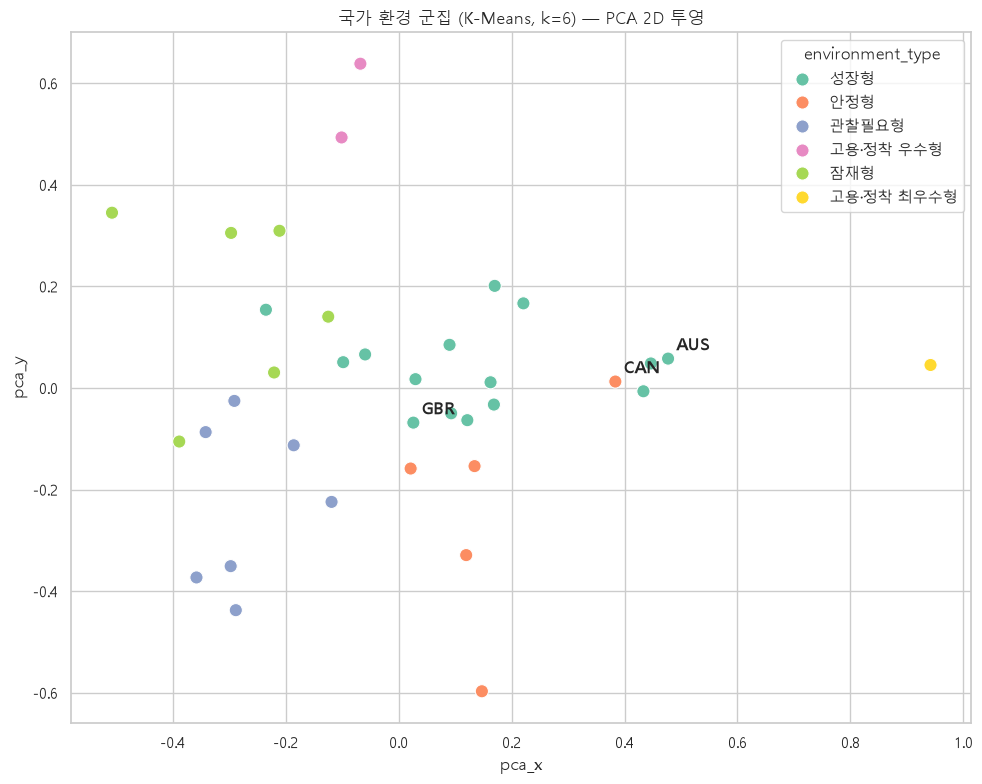

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
df["pca_x"], df["pca_y"] = coords[:, 0], coords[:, 1]
print("PCA 2개 축 설명 분산 비율:", pca.explained_variance_ratio_.round(3), "합계:", pca.explained_variance_ratio_.sum().round(3))

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=df, x="pca_x", y="pca_y", hue="environment_type", palette="Set2", s=90, ax=ax)
for _, row in df[df["iso3"].isin(MVP_COUNTRIES)].iterrows():
    ax.annotate(row["iso3"], (row["pca_x"], row["pca_y"]), fontsize=12, fontweight="bold",
                xytext=(6, 6), textcoords="offset points")
ax.set_title(f"국가 환경 군집 (K-Means, k={best_k}) — PCA 2D 투영")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_cluster_pca_scatter.png", dpi=150)
plt.show()

### MVP 3개국 결과

In [11]:
mvp_result = df[df["iso3"].isin(MVP_COUNTRIES)][
    ["iso3", "country_name", "cluster", "environment_type", "environment_score"]
].sort_values("environment_score", ascending=False)
mvp_result

,iso3,country_name,cluster,environment_type,environment_score
3,CAN,Canada,2,안정형,53.59
0,AUS,Australia,1,성장형,49.42
14,GBR,United Kingdom,1,성장형,42.63


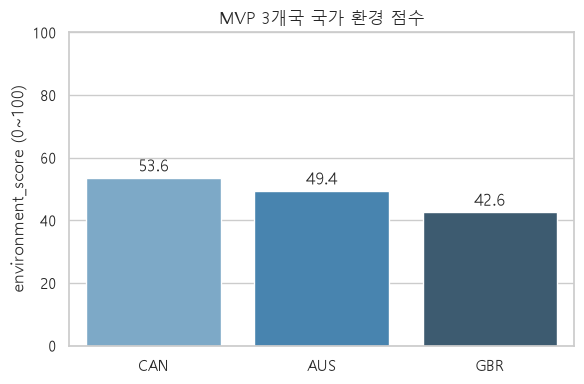

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=mvp_result, x="iso3", y="environment_score", hue="iso3", palette="Blues_d", legend=False, ax=ax)
ax.set_ylim(0, 100)
ax.set_title("MVP 3개국 국가 환경 점수")
ax.set_xlabel("")
ax.set_ylabel("environment_score (0~100)")
for i, row in enumerate(mvp_result.itertuples()):
    ax.text(i, row.environment_score + 2, f"{row.environment_score:.1f}", ha="center")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_mvp_environment_scores.png", dpi=150)
plt.show()

## 6. 모델 저장

In [13]:
joblib.dump(final_kmeans, MODELS_DIR / "environment_kmeans.joblib")
joblib.dump(scaler, MODELS_DIR / "environment_scaler.joblib")

features_payload = {
    "modelVersion": "environment-kmeans-1.0.0",
    "dataVersion": "2026-07-17",
    "featureColumns": RAW_FEATURES,
    "k": int(best_k),
    "clusterTypeMap": {str(k): v for k, v in cluster_type_map.items()},
    "countryScores": {
        row["iso3"]: {
            "cluster": int(row["cluster"]),
            "environmentType": row["environment_type"],
            "environmentScore": float(row["environment_score"]),
        }
        for _, row in df.iterrows()
    },
}

with open(MODELS_DIR / "environment_features.json", "w", encoding="utf-8") as f:
    json.dump(features_payload, f, ensure_ascii=False, indent=2)

print("저장 완료:", MODELS_DIR.resolve())
print("MVP 3개국:", {c: features_payload["countryScores"][c] for c in MVP_COUNTRIES})

저장 완료: F:\living_abroad\ai-server\models
MVP 3개국: {'CAN': {'cluster': 2, 'environmentType': '안정형', 'environmentScore': 53.59}, 'AUS': {'cluster': 1, 'environmentType': '성장형', 'environmentScore': 49.42}, 'GBR': {'cluster': 1, 'environmentType': '성장형', 'environmentScore': 42.63}}


## 결론

- 전체 36개국으로 K-Means를 학습하고, 결과에서 캐나다·호주·영국만 조회했다.
- `environment_score`는 9개 정규화 피처의 단순 평균(0~100)이며, `environment_score_rule_based`는 비교 참고용으로만 사용했다 (학습 라벨 아님).
- 군집(`environmentType`)은 국가 환경 유형을 설명하는 보조 정보이며, 실제 서비스 점수는 `environment_score`를 사용한다.
- 저장된 모델(`environment_kmeans.joblib`, `environment_scaler.joblib`, `environment_features.json`)은 `ai-server`가 기동 시 로딩해 `/ai/recommend`의 `environmentScore`를 대체하는 데 사용한다.
- 실험 결과 요약은 `document_JinAhKwak/01_environment_kmeans_results.md`에 별도 정리한다.